##### Objetivo: El objetivo de esta práctica es que los estudiantes implementen y entrenen una red neuronal profunda utilizando una biblioteca de Machine Learning (como TensorFlow) para resolver un problema de clasificación de imágenes.

In [1]:
#####PASO 1
#Importe de librerias
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
#####PASO 2
#Carga el dataset MNIST usando las funciones proporcionadas por la biblioteca seleccionada,
#y divídelo en conjunto de entrenamiento y prueba.
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

In [3]:
# Normaliza los valores de píxeles a un rango de [0, 1]
train_images = train_images / 255.0
test_images = test_images / 255.0

In [16]:
#####PASO 3
#Define una red neuronal profunda utilizando varias capas densas y una capa de activación softmax al final para la clasificación multiclase.

model = models.Sequential([layers.Flatten(input_shape=(28, 28)), #Toma un entrada bidimensional (imagen 28x28)
                           layers.Dense(500, activation='relu'), #Primera capa oculta, con 128 neuronas y función de activación RELU
                           layers.Dense(250, activation='relu'), #Segunda capa oculta, con 64 neuronas
                           layers.Dense(10, activation='softmax')]) #Capa de salida con 10 neuronas, una por cada clase (10 clases para los dígitos del 0 al 9)

#La activación softmax convierte los valores en probabilidades, indicando la probabilidad de que una entrada pertenezca a cada clase.

c:\Users\Usuario\programacion\bootcampIA\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
#####PASO 4
#Compila el modelo especificando el optimizador, la función de pérdida y las métricas de evaluación.
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [18]:
#####PASO 5
#Entrena la red utilizando el conjunto de datos de entrenamiento y evalúa su rendimiento en el conjunto de prueba.
historial = model.fit(train_images, train_labels, epochs=5, validation_data=(test_images, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9441 - loss: 0.1878 - val_accuracy: 0.9612 - val_loss: 0.1233
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9746 - loss: 0.0810 - val_accuracy: 0.9745 - val_loss: 0.0868
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9823 - loss: 0.0561 - val_accuracy: 0.9772 - val_loss: 0.0742
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9858 - loss: 0.0433 - val_accuracy: 0.9706 - val_loss: 0.1016
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9892 - loss: 0.0327 - val_accuracy: 0.9797 - val_loss: 0.0738


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9735 - loss: 0.0840
Test accuracy: 0.9735000133514404
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


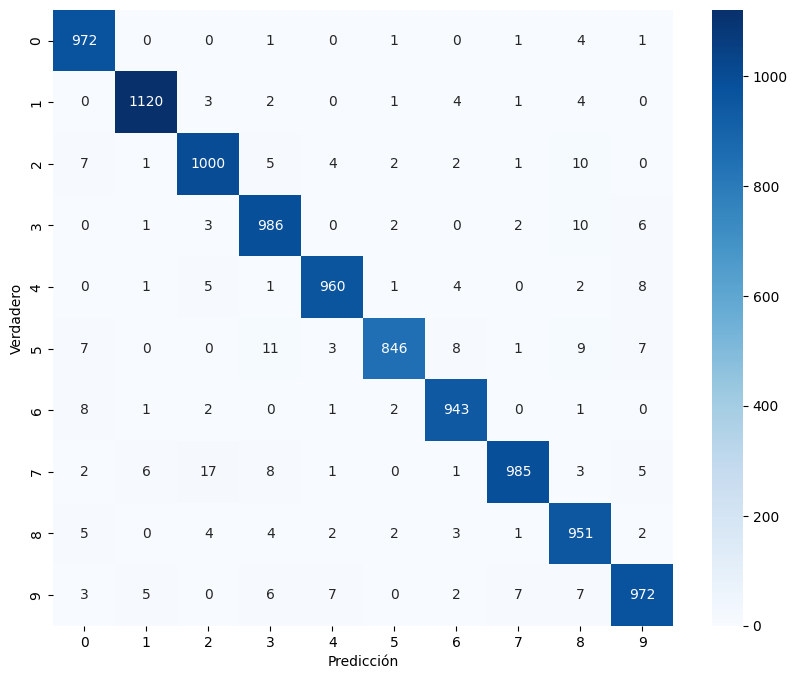

Generando Matriz de Confusión...
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Proceso completado.


In [15]:
#####PASO 6 Evaluación
#Evalúa la red neuronal en los datos de prueba y genera una matriz de confusión para visualizar el rendimiento.
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'Test accuracy: {test_acc}')

# Matriz de Confusión
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)
confusion_mtx = confusion_matrix(test_labels, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()
print("Generando Matriz de Confusión...")
# Predecir clases
y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)

# Calcular matriz
cm = confusion_matrix(test_labels, y_pred_classes)


print("Proceso completado.")